<a href="https://colab.research.google.com/github/elli1zabeth/projekt/blob/main/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Współtwórcy - Jakub Majzoub, Yelyzaveta Merliuk, Łukasz Rakoczy

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [14]:
file_path = "NY-House-Dataset.csv"

try:
    df = pd.read_csv(file_path, delimiter=",", quoting=3, on_bad_lines='skip')
    print("Plik wczytany poprawnie.")
except pd.errors.ParserError as e:
    print(f"Błąd parsowania CSV: {e}")
    line_number = int(str(e).split("line ")[1].split(",")[0])

    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == line_number - 1:
                print(f"Problematic line {line_number}: {line.strip()}")
                break


    try:
        df = pd.read_csv(file_path, delimiter=";")
        print("Plik wczytany poprawnie z separatorem ';'.")
    except Exception as e:
        print(f"Nie udało się wczytać pliku nawet z innym separatorem: {e}")

# Wyświetl pierwsze 5 wierszy dla sprawdzenia
print(df.head())

Plik wczytany poprawnie.
                                                                                                                                                                                                              BROKERTITLE;TYPE;PRICE;BEDS;BATH;PROPERTYSQFT;ADDRESS;STATE;MAIN_ADDRESS;ADMINISTRATIVE_AREA_LEVEL_2;LOCALITY;SUBLOCALITY;STREET_NAME;LONG_NAME;FORMATTED_ADDRESS;LATITUDE;LONGITUDE
Brokered by Douglas Elliman  -111 Fifth Ave;Con... NY 10022;2 E 55th St Unit 803New York              NY 10022;New York County;New York;Manhattan;Eas... 2 E 55th St #803 New York NY 10022                                            USA;40.761255;-73.9744834                                                                                                                                  
Brokered by Serhant;Condo for sale;195000000;7;... NY 10019;Central Park Tower Penthouse-217 W 57t... NY 10019;United States;New York;New York County... New York         NY 10019 USA;40.7663935;-73.980

In [15]:
df.shape

(4783, 1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4783 entries, ('Brokered by Douglas Elliman  -111 Fifth Ave;Condo for sale;315000;2;2;1400;2 E 55th St Unit 803;New York', ' NY 10022;2 E 55th St Unit 803New York', ' NY 10022;New York County;New York;Manhattan;East 55th Street;Regis Residence;Regis Residence', ' 2 E 55th St #803', ' New York', ' NY 10022') to ('Brokered by Nyc Realty Brokers Llc;Co-op for sale;349000;1;1;750;460 Neptune Ave Apt 14O;Brooklyn', ' NY 11224;460 Neptune Ave Apt 14OBrooklyn', ' NY 11224;New York;Kings County;Brooklyn;Coney Island;460;460 Neptune Ave #14a', ' Brooklyn', ' NY 11224', ' USA;40.579147;-73.9709488')
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                    

In [17]:
df = pd.read_csv(file_path, sep=';')

df.columns = df.columns.str.lower()
df.drop_duplicates(inplace=True)

columns_to_drop = [
    'address',
    'state',
    'main_address',
    'administrative_area_level_2',
    'locality',
    'street_name',
    'long_name',
    'latitude',
    'longitude'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


df.to_csv('przetworzony_plik.csv', index=False)

print(df.shape)
print(df.columns)
print(df.head(100))

(4587, 8)
Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'sublocality', 'formatted_address'],
      dtype='object')
                                           brokertitle                type  \
0          Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                  Brokered by Serhant      Condo for sale   
2                               Brokered by Sowae Corp      House for sale   
3                                  Brokered by COMPASS      Condo for sale   
4    Brokered by Sotheby's International Realty - E...  Townhouse for sale   
..                                                 ...                 ...   
96      Brokered by Douglas Elliman - 3544 Johnson Ave      Co-op for sale   
97                              Brokered by Sowae Corp      House for sale   
98           Brokered by Americas Real Estate Advisors      House for sale   
99       Brokered by Douglas Elliman - 575 Madison Ave      House for sal

In [18]:
# sort

df_sorted = df.sort_values(by='price')
print(df_sorted.head(100))


                                brokertitle            type   price  beds  \
317     Brokered by Living NY - Main Office        For sale    2494     2   
310     Brokered by Living NY - Main Office        For sale    3225     3   
360     Brokered by Century 21 Realty First   Land for sale    5800     3   
463    Brokered by Morris Park Realty Group  Co-op for sale   49500     3   
979                     Brokered by COMPASS  Condo for sale   60000     3   
...                                     ...             ...     ...   ...   
1527  Brokered by Keller Williams Ny Realty  Co-op for sale  170000     2   
1135              Brokered by Pride Estates         Pending  172800     1   
3948   Brokered by Goldstone N Y Realty Llc  Co-op for sale  173000     3   
1517         Brokered by TRACEY REAL ESTATE  Co-op for sale  174000     1   
1468         Brokered by Pantiga Group Inc.  Co-op for sale  175000     1   

          bath  propertysqft sublocality  \
317   1.000000   2184.207862   

In [19]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip('_')
        df[col] = df[col].str.strip('-')
        df[col] = df[col].replace(' ', np.nan)
df.info()
print(df.head(100))

<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brokertitle        4587 non-null   object 
 1   type               4587 non-null   object 
 2   price              4587 non-null   int64  
 3   beds               4587 non-null   int64  
 4   bath               4587 non-null   float64
 5   propertysqft       4587 non-null   float64
 6   sublocality        4587 non-null   object 
 7   formatted_address  4587 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 322.5+ KB
                                           brokertitle                type  \
0          Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                  Brokered by Serhant      Condo for sale   
2                               Brokered by Sowae Corp      House for sale   
3                                  Brokered

In [20]:
for col in ['bath', 'propertysqft']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['bath'] = df['bath'].astype(str).str.rstrip('0').str.rstrip('.')
df['propertysqft'] = df['propertysqft'].astype(str).str.rstrip('0').str.rstrip('.')

df['price'] = df['price'].astype(str)

print(df.head(5))

                                         brokertitle                type  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       price  beds                bath propertysqft      sublocality  \
0     315000     2                   2         1400        Manhattan   
1  195000000     7                  10        17545  New York County   
2     260000     4                   2         2015  Richmond County   
3      69000     3                   1          445  New York County   
4   55000000     7  2.3738608579684373        14175  New York County   

                                   formatted_address  
0  Regis Residence, 2 E 55th St #803, New York, N...  


In [21]:
print(df.head(5))

                                         brokertitle                type  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       price  beds                bath propertysqft      sublocality  \
0     315000     2                   2         1400        Manhattan   
1  195000000     7                  10        17545  New York County   
2     260000     4                   2         2015  Richmond County   
3      69000     3                   1          445  New York County   
4   55000000     7  2.3738608579684373        14175  New York County   

                                   formatted_address  
0  Regis Residence, 2 E 55th St #803, New York, N...  


In [22]:
df['type'] = df['type'].str.replace(' for sale', '', regex=False)

In [23]:
print(df.head(5))

                                         brokertitle       type      price  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo     315000   
1                                Brokered by Serhant      Condo  195000000   
2                             Brokered by Sowae Corp      House     260000   
3                                Brokered by COMPASS      Condo      69000   
4  Brokered by Sotheby's International Realty - E...  Townhouse   55000000   

   beds                bath propertysqft      sublocality  \
0     2                   2         1400        Manhattan   
1     7                  10        17545  New York County   
2     4                   2         2015  Richmond County   
3     3                   1          445  New York County   
4     7  2.3738608579684373        14175  New York County   

                                   formatted_address  
0  Regis Residence, 2 E 55th St #803, New York, N...  
1             217 W 57th St, New York, NY 10019, USA  

In [24]:
# prompt: usuń kolumny brokertitle i formatted_address

columns_to_drop = ['brokertitle', 'formatted_address','address']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [25]:
df.dtypes

,0
type,object
price,object
beds,int64
bath,object
propertysqft,object
sublocality,object


In [26]:
df.shape

(4587, 6)

In [27]:
print(df)

           type      price  beds                bath propertysqft  \
0         Condo     315000     2                   2         1400   
1         Condo  195000000     7                  10        17545   
2         House     260000     4                   2         2015   
3         Condo      69000     3                   1          445   
4     Townhouse   55000000     7  2.3738608579684373        14175   
...         ...        ...   ...                 ...          ...   
4796      Co-op     599000     1                   1  2184.207862   
4797      Co-op     245000     1                   1  2184.207862   
4798      Co-op    1275000     1                   1  2184.207862   
4799      Condo     598125     2                   1          655   
4800      Co-op     349000     1                   1          750   

          sublocality  
0           Manhattan  
1     New York County  
2     Richmond County  
3     New York County  
4     New York County  
...               ...  
479

In [28]:
le_type = LabelEncoder()
le_sublocality = LabelEncoder()

df['type'] = le_type.fit_transform(df['type'])
df['sublocality'] = le_sublocality.fit_transform(df['sublocality'])

for class_label, original_value in enumerate(le_type.classes_):
    print(f"Type: {class_label} represents: {original_value}")
for class_label, original_value in enumerate(le_sublocality.classes_):
    print(f"Sublocality: {class_label} represents: {original_value}")

Type: 0 represents: Co-op
Type: 1 represents: Coming Soon
Type: 2 represents: Condo
Type: 3 represents: Condop
Type: 4 represents: Contingent
Type: 5 represents: For sale
Type: 6 represents: Foreclosure
Type: 7 represents: House
Type: 8 represents: Land
Type: 9 represents: Mobile house
Type: 10 represents: Multi-family home
Type: 11 represents: Pending
Type: 12 represents: Townhouse
Sublocality: 0 represents: Bronx County
Sublocality: 1 represents: Brooklyn
Sublocality: 2 represents: Brooklyn Heights
Sublocality: 3 represents: Coney Island
Sublocality: 4 represents: Dumbo
Sublocality: 5 represents: East Bronx
Sublocality: 6 represents: Flushing
Sublocality: 7 represents: Fort Hamilton
Sublocality: 8 represents: Jackson Heights
Sublocality: 9 represents: Kings County
Sublocality: 10 represents: Manhattan
Sublocality: 11 represents: New York
Sublocality: 12 represents: New York County
Sublocality: 13 represents: Queens
Sublocality: 14 represents: Queens County
Sublocality: 15 represents:

In [29]:
print(df.head(5))

   type      price  beds                bath propertysqft  sublocality
0     2     315000     2                   2         1400           10
1     2  195000000     7                  10        17545           12
2     7     260000     4                   2         2015           16
3     2      69000     3                   1          445           12
4    12   55000000     7  2.3738608579684373        14175           12


#Adjustment wszystkich danych do Int64 26.04

In [30]:
df.dtypes

,0
type,int64
price,object
beds,int64
bath,object
propertysqft,object
sublocality,int64


In [31]:
df.shape

(4587, 6)

In [32]:
def auto_convert_object_to_int(df):

  object_cols = df.select_dtypes(include=['object']).columns
  converted_cols = {}

  for col in object_cols:
        try:
            # Attempt to convert the column to numeric, coercing errors to NaN
            numeric_series = pd.to_numeric(df[col], errors='coerce')

            # Check if all non-NaN values in the numeric series are whole numbers
            if numeric_series.notna().all() and (numeric_series % 1 == 0).all():
                converted_cols[col] = numeric_series.astype('Int64')
            else:
                print(f"Column '{col}' contains non-integer values and was not converted.")
        except Exception as e:
            print(f"Error processing column '{col}': {e}")


  df = df.assign(**converted_cols)
  return df

# Apply the automatic conversion function
df_converted = auto_convert_object_to_int(df.copy()) # Use .copy() to avoid modifying the original DataFrame directly

# Display the DataFrame info to verify the data types
print("\nDataFrame info after automatic conversion:")
print(df_converted.info())

# You can also display the first few rows to see the changes
print("\nFirst few rows of the converted DataFrame:")
df_converted.dtypes

Column 'bath' contains non-integer values and was not converted.
Column 'propertysqft' contains non-integer values and was not converted.

DataFrame info after automatic conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          4587 non-null   int64 
 1   price         4587 non-null   Int64 
 2   beds          4587 non-null   int64 
 3   bath          4587 non-null   object
 4   propertysqft  4587 non-null   object
 5   sublocality   4587 non-null   int64 
dtypes: Int64(1), int64(3), object(2)
memory usage: 255.3+ KB
None

First few rows of the converted DataFrame:


,0
type,int64
price,Int64
beds,int64
bath,object
propertysqft,object
sublocality,int64


In [33]:
# Assuming your DataFrame is named 'df' (the one you loaded earlier)

def display_non_integer_values(df, column_name):
    """
    Displays unique non-integer or non-numeric values in a specified column
    that was originally of 'object' dtype.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to inspect.
    """
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    if df[column_name].dtype != 'object':
        print(f"Column '{column_name}' is not of 'object' dtype. Its dtype is: {df[column_name].dtype}")
        return

    # Convert to numeric, coercing errors to NaN
    numeric_series = pd.to_numeric(df[column_name], errors='coerce')

    # Identify rows where the original value is not NaN after numeric conversion
    # AND either has a non-zero fractional part OR is NaN (meaning it couldn't be numeric)
    non_integer_df = df[df[column_name].notna() & ((numeric_series.isna()) | (numeric_series % 1 != 0))]

    if not non_integer_df.empty:
        print(f"\nNon-integer or non-numeric values in column '{column_name}':")
        print(non_integer_df[column_name].unique())
    else:
        print(f"\nNo non-integer or non-numeric values found in column '{column_name}' that prevented conversion.")

# Display the problematic values for 'bath'
display_non_integer_values(df, 'bath')

# Display the problematic values for 'propertysqft'
display_non_integer_values(df, 'propertysqft')


Non-integer or non-numeric values in column 'bath':
['2.3738608579684373']

Non-integer or non-numeric values in column 'propertysqft':
['2184.207862']


In [34]:
import pandas as pd
import math

# Assuming your DataFrame is named 'df'

columns_to_round_up = ['bath', 'propertysqft']

for col in columns_to_round_up:
    # Convert the column to numeric first (coerces non-numeric to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Apply ceil to non-NaN values and then convert to Int64
    df[col] = df[col].apply(lambda x: math.ceil(x) if pd.notna(x) else x).astype('Int64')

# Display the DataFrame info to verify the data types
print(df.info())

# You can also display the first few rows to see the changes
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          4587 non-null   int64 
 1   price         4587 non-null   object
 2   beds          4587 non-null   int64 
 3   bath          4587 non-null   Int64 
 4   propertysqft  4587 non-null   Int64 
 5   sublocality   4587 non-null   int64 
dtypes: Int64(2), int64(3), object(1)
memory usage: 259.8+ KB
None
   type      price  beds  bath  propertysqft  sublocality
0     2     315000     2     2          1400           10
1     2  195000000     7    10         17545           12
2     7     260000     4     2          2015           16
3     2      69000     3     1           445           12
4    12   55000000     7     3         14175           12


In [35]:
def auto_convert_object_to_int(df):

  object_cols = df.select_dtypes(include=['object']).columns
  converted_cols = {}

  for col in object_cols:
        try:
            # Attempt to convert the column to numeric, coercing errors to NaN
            numeric_series = pd.to_numeric(df[col], errors='coerce')

            # Check if all non-NaN values in the numeric series are whole numbers
            if numeric_series.notna().all() and (numeric_series % 1 == 0).all():
                converted_cols[col] = numeric_series.astype('Int64')
            else:
                print(f"Column '{col}' contains non-integer values and was not converted.")
        except Exception as e:
            print(f"Error processing column '{col}': {e}")


  df = df.assign(**converted_cols)
  return df

# Apply the automatic conversion function
df_converted = auto_convert_object_to_int(df.copy()) # Use .copy() to avoid modifying the original DataFrame directly

# Display the DataFrame info to verify the data types
print("\nDataFrame info after automatic conversion:")
print(df_converted.info())

# You can also display the first few rows to see the changes
print("\nFirst few rows of the converted DataFrame:")
df_converted.dtypes


DataFrame info after automatic conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          4587 non-null   int64
 1   price         4587 non-null   Int64
 2   beds          4587 non-null   int64
 3   bath          4587 non-null   Int64
 4   propertysqft  4587 non-null   Int64
 5   sublocality   4587 non-null   int64
dtypes: Int64(3), int64(3)
memory usage: 264.3 KB
None

First few rows of the converted DataFrame:


,0
type,int64
price,Int64
beds,int64
bath,Int64
propertysqft,Int64
sublocality,int64


In [36]:
df.dtypes

,0
type,int64
price,object
beds,int64
bath,Int64
propertysqft,Int64
sublocality,int64


In [37]:
import pandas as pd

# Assuming your DataFrame is named 'df'

def convert_to_nullable_int(df):
    """
    Converts all suitable columns in a DataFrame to the pandas nullable integer type Int64.
    Suitable columns are those with current dtype 'int64' or 'object' that can be
    safely converted to integers (whole numbers, no non-numeric characters).

    Args:
        df (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: The DataFrame with suitable columns converted to 'Int64'.
    """
    for col in df.columns:
        if df[col].dtype == 'int64':
            try:
                df[col] = df[col].astype('Int64')
                print(f"Column '{col}' converted from int64 to Int64.")
            except Exception as e:
                print(f"Error converting column '{col}' from int64 to Int64: {e}")
        elif df[col].dtype == 'object':
            try:
                # Attempt to convert to numeric, coercing errors
                numeric_series = pd.to_numeric(df[col], errors='coerce')
                # Check if all non-NaN values are whole numbers
                if numeric_series.notna().all() and (numeric_series % 1 == 0).all():
                    df[col] = numeric_series.astype('Int64')
                    print(f"Column '{col}' (object) converted to Int64.")
                else:
                    print(f"Column '{col}' (object) contains non-integer values and was not converted to Int64.")
            except Exception as e:
                print(f"Error processing column '{col}' (object): {e}")
    return df

# Apply the conversion function
df = convert_to_nullable_int(df.copy()) # Use .copy() to avoid modifying the original DataFrame directly

# Display the DataFrame info to verify the data types
print("\nDataFrame info after attempting conversion to Int64:")
print(df.info())

Column 'type' converted from int64 to Int64.
Column 'price' (object) converted to Int64.
Column 'beds' converted from int64 to Int64.
Column 'sublocality' converted from int64 to Int64.

DataFrame info after attempting conversion to Int64:
<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          4587 non-null   Int64
 1   price         4587 non-null   Int64
 2   beds          4587 non-null   Int64
 3   bath          4587 non-null   Int64
 4   propertysqft  4587 non-null   Int64
 5   sublocality   4587 non-null   Int64
dtypes: Int64(6)
memory usage: 277.7 KB
None


In [38]:
df.dtypes

,0
type,Int64
price,Int64
beds,Int64
bath,Int64
propertysqft,Int64
sublocality,Int64


#Kontynuacja


In [39]:
df_sorted = df.sort_values(by='price')
print(df_sorted.head(4000))

      type    price  beds  bath  propertysqft  sublocality
317      5     2494     2     1          2185           11
310      5     3225     3     1          2185           11
360      8     5800     3     3          2185            1
463      0    49500     3     3           800           20
979      2    60000     3     1           445           11
...    ...      ...   ...   ...           ...          ...
4142     0  2750000     2     2          2185           11
2209     2  2750000     2     2          1892           11
644      7  2750000     6     5          6300           16
3958     2  2750000     2     2          1488           11
897      7  2750000     3     5          4600            9

[4000 rows x 6 columns]


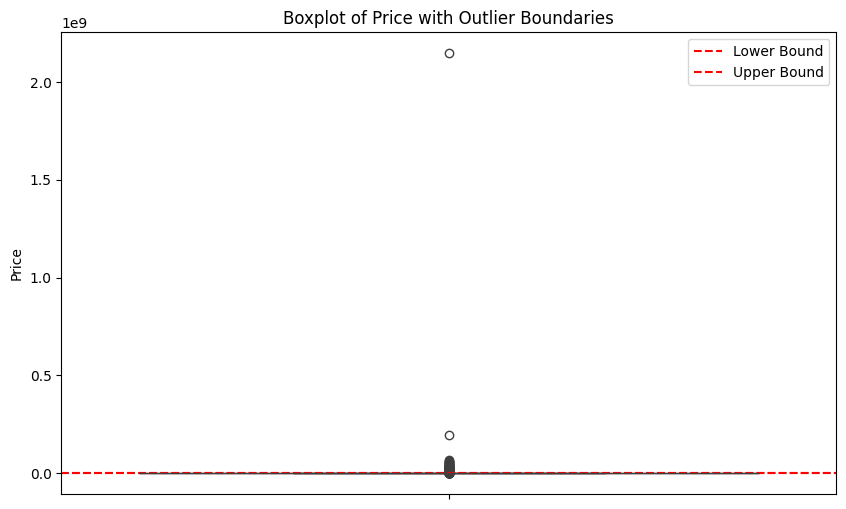

In [40]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.boxplot(y='price', data=df)

# Calculate outlier boundaries
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Add red lines for outlier boundaries
plt.axhline(y=lower_bound, color='r', linestyle='--', label='Lower Bound')
plt.axhline(y=upper_bound, color='r', linestyle='--', label='Upper Bound')

plt.title('Boxplot of Price with Outlier Boundaries')
plt.ylabel('Price')
plt.legend()
plt.show()


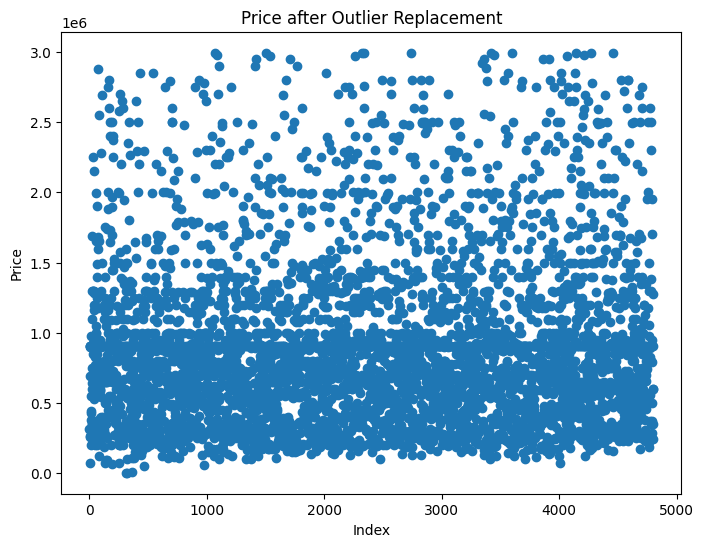

In [41]:
# Zastąpienie wartości odstających w 'price' średnią
mean_price = df['price'][(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].mean()
df.loc[(df['price'] < lower_bound) | (df['price'] > upper_bound), 'price'] = int(round(mean_price))

# Wykres po usunięciu wartości odstających
plt.figure(figsize=(8, 6))
plt.plot(df['price'], marker='o', linestyle='')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Price after Outlier Replacement')
plt.show()

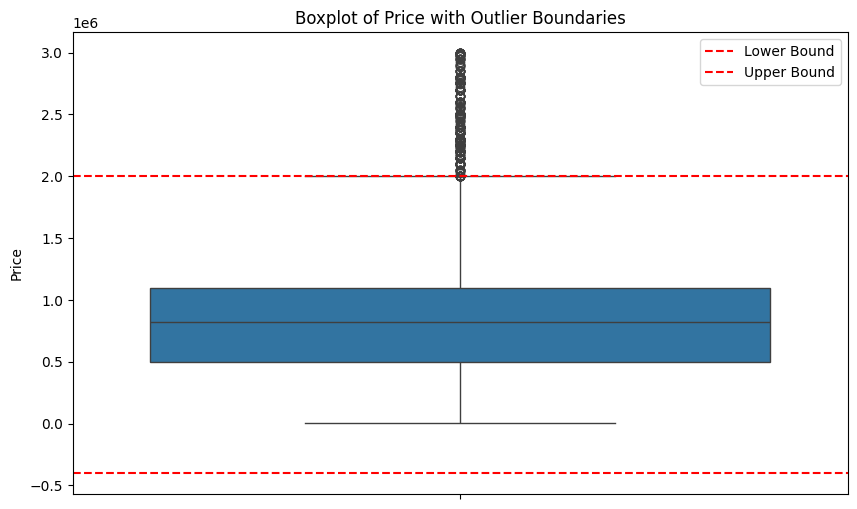

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(y='price', data=df)

# Calculate outlier boundaries
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Add red lines for outlier boundaries
plt.axhline(y=lower_bound, color='r', linestyle='--', label='Lower Bound')
plt.axhline(y=upper_bound, color='r', linestyle='--', label='Upper Bound')

plt.title('Boxplot of Price with Outlier Boundaries')
plt.ylabel('Price')
plt.legend()
plt.show()

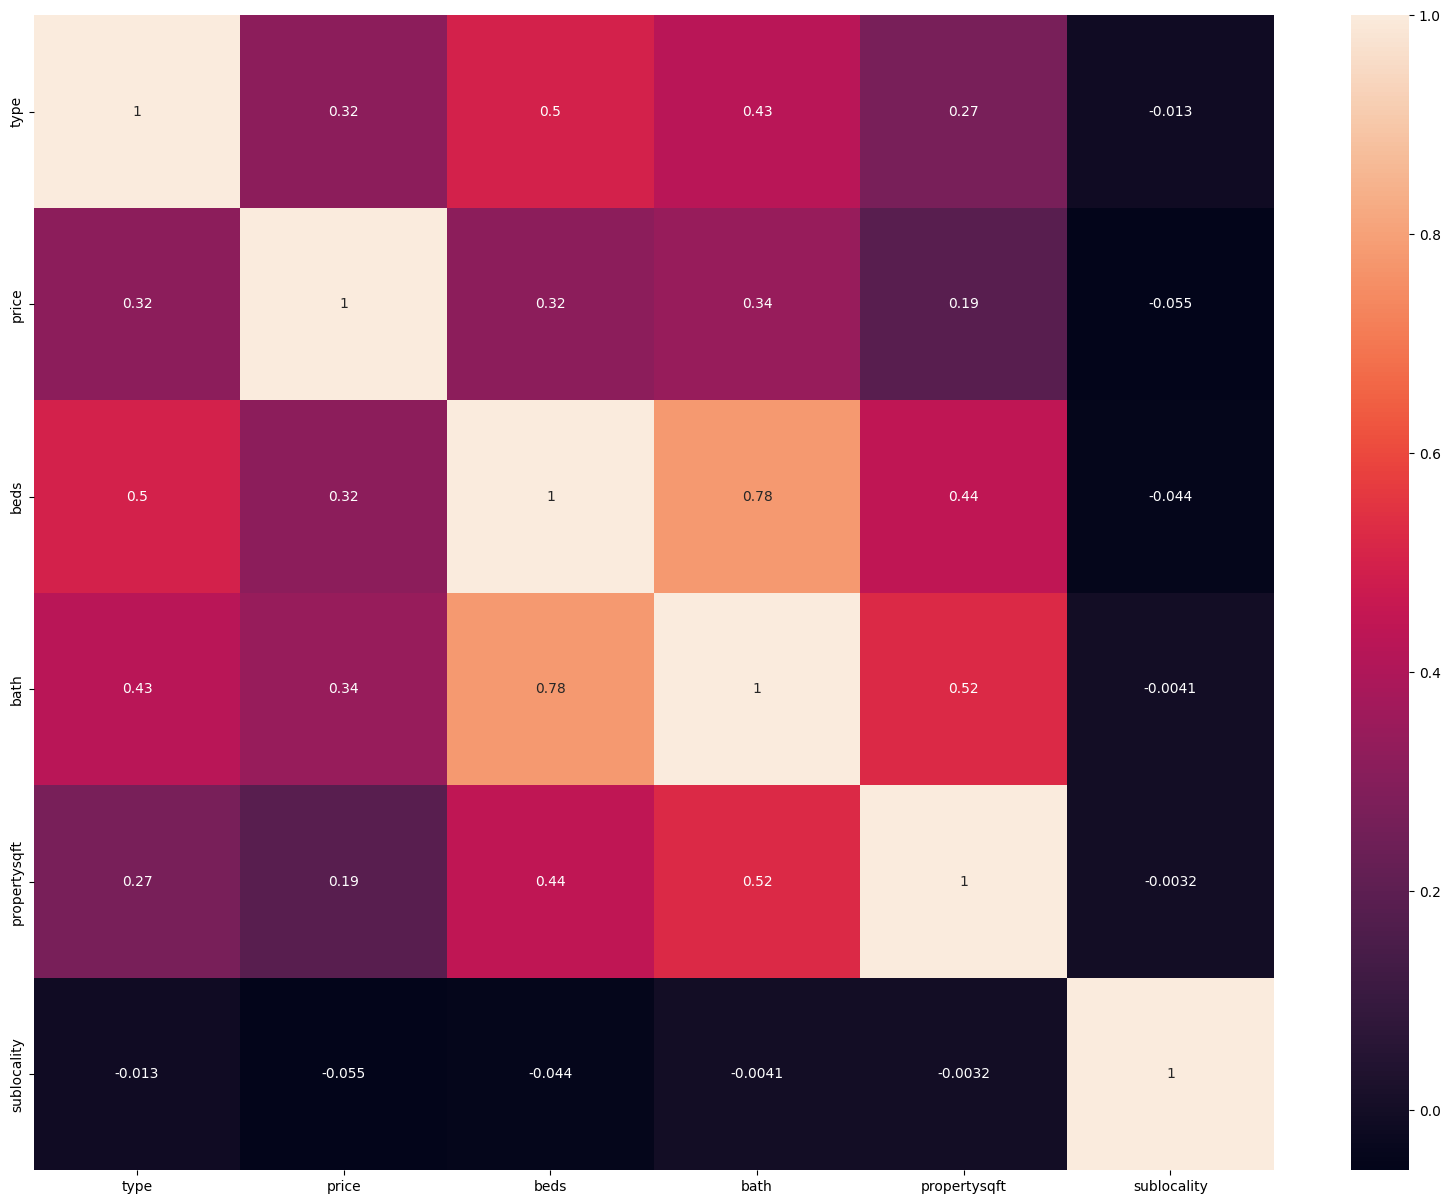

In [43]:
corr_matrix = df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True)
plt.show()

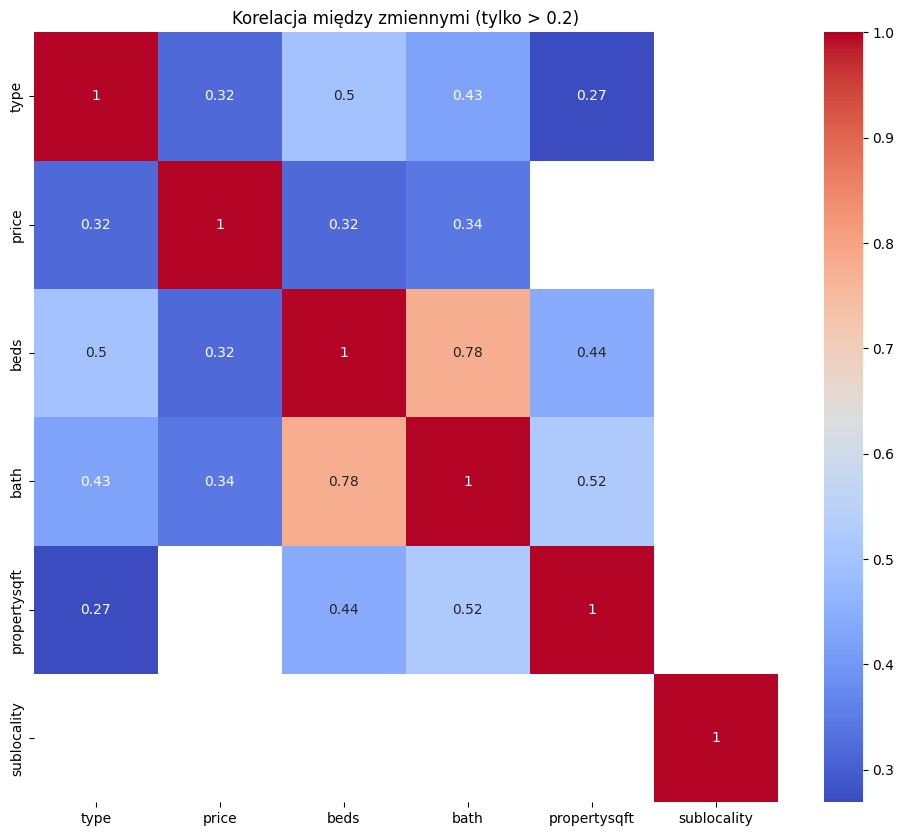

In [44]:
#Pokaz korelacje między zmiennymi tylko jesli są większe od 0.2
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[abs(corr_matrix) > 0.2], annot=True, cmap='coolwarm')
plt.title('Korelacja między zmiennymi (tylko > 0.2)')
plt.show()

In [45]:
scaler = MinMaxScaler() # scaler = StandardScaler()
col_float = ['type', 'price', 'beds', 'bath', 'propertysqft',
       'sublocality']

for i in df[col_float]:
  df[i] = scaler.fit_transform(df[[i]])

print(df.head())

       type     price      beds  bath  propertysqft  sublocality
0  0.166667  0.104430  0.020408  0.04      0.017916          0.5
1  0.166667  0.301063  0.122449  0.20      0.265140          0.6
2  0.583333  0.086050  0.061224  0.04      0.027333          0.8
3  0.166667  0.022224  0.040816  0.02      0.003292          0.6
4  1.000000  0.301063  0.122449  0.06      0.213536          0.6


#Część II


In [46]:
df.columns

Index(['type', 'price', 'beds', 'bath', 'propertysqft', 'sublocality'], dtype='object')

In [47]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler

train and test data


In [48]:
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
regressor = LinearRegression().fit(X_train, y_train)

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score

# Przewidywanie na zbiorze testowym
y_pred = regressor.predict(X_test)

# Obliczanie miar
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

# Wypisywanie wyników
print(f"Średni błąd kwadratowy (MSE): {mse:.2f}")
print(f"Średni błąd absolutny (MAE): {mae:.2f}")
print(f"Wynik wyjaśnionej wariancji (EVS): {evs:.2f}")

Średni błąd kwadratowy (MSE): 0.03
Średni błąd absolutny (MAE): 0.13
Wynik wyjaśnionej wariancji (EVS): 0.16


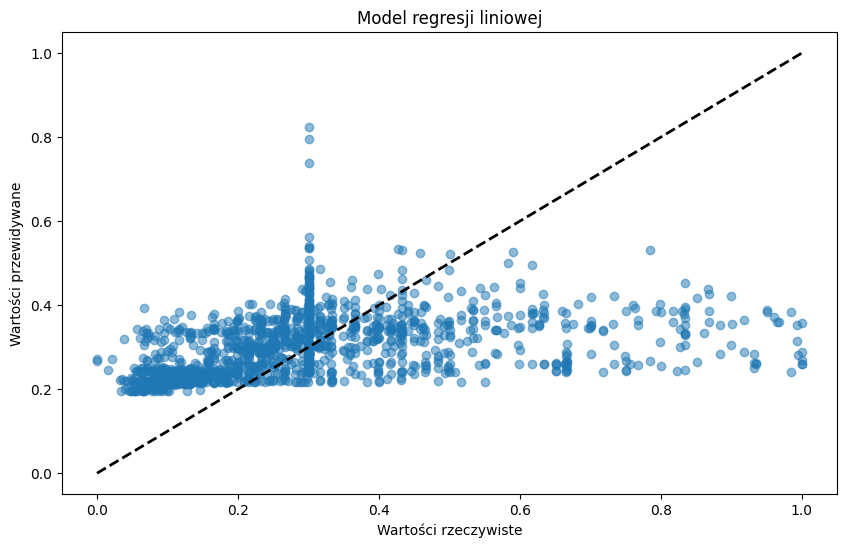

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidywane')
plt.title('Model regresji liniowej')
plt.show()


KNeighborsRegressor Results:
Średni błąd kwadratowy (MSE): 0.02
Średni błąd absolutny (MAE): 0.10
Wynik wyjaśnionej wariancji (EVS): 0.43


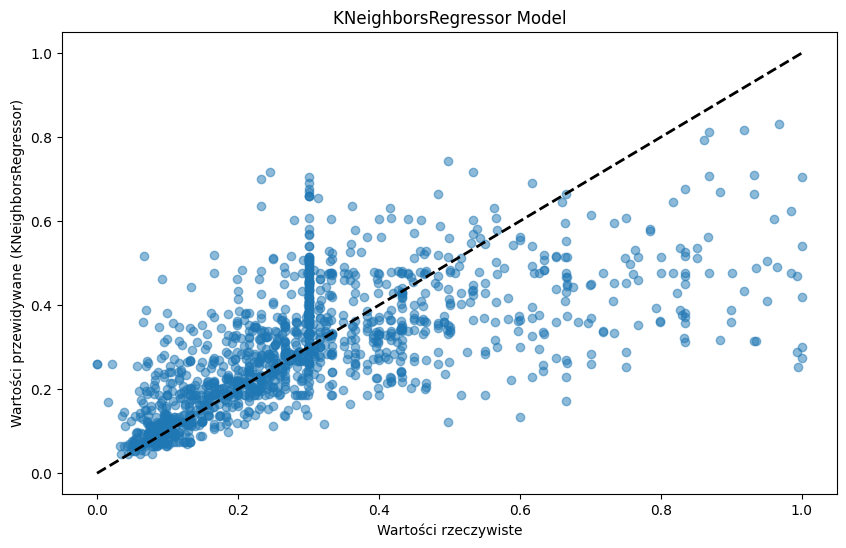

In [54]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

y_pred_knn = knn_regressor.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
evs_knn = explained_variance_score(y_test, y_pred_knn)

print("\nKNeighborsRegressor Results:")
print(f"Średni błąd kwadratowy (MSE): {mse_knn:.2f}")
print(f"Średni błąd absolutny (MAE): {mae_knn:.2f}")
print(f"Wynik wyjaśnionej wariancji (EVS): {evs_knn:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidywane (KNeighborsRegressor)')
plt.title('KNeighborsRegressor Model')
plt.show()


RandomForestRegressor Results:
Średni błąd kwadratowy (MSE): 0.02
Średni błąd absolutny (MAE): 0.10
Wynik wyjaśnionej wariancji (EVS): 0.44
Współczynnik determinacji (R-squared): 0.44


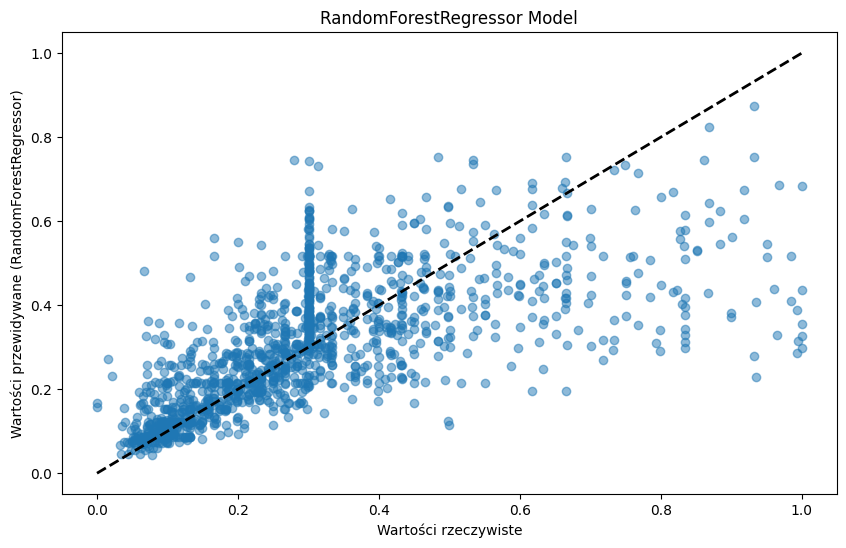

In [56]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(X_train, y_train)

y_pred_rf = rf_regressor.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
evs_rf = explained_variance_score(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandomForestRegressor Results:")
print(f"Średni błąd kwadratowy (MSE): {mse_rf:.2f}")
print(f"Średni błąd absolutny (MAE): {mae_rf:.2f}")
print(f"Wynik wyjaśnionej wariancji (EVS): {evs_rf:.2f}")
print(f"Współczynnik determinacji (R-squared): {r2_rf:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidywane (RandomForestRegressor)')
plt.title('RandomForestRegressor Model')
plt.show()


DecisionTreeRegressor Results:
Średni błąd kwadratowy (MSE): 0.03
Średni błąd absolutny (MAE): 0.11
Wynik wyjaśnionej wariancji (EVS): 0.17
Współczynnik determinacji (R-squared): 0.17


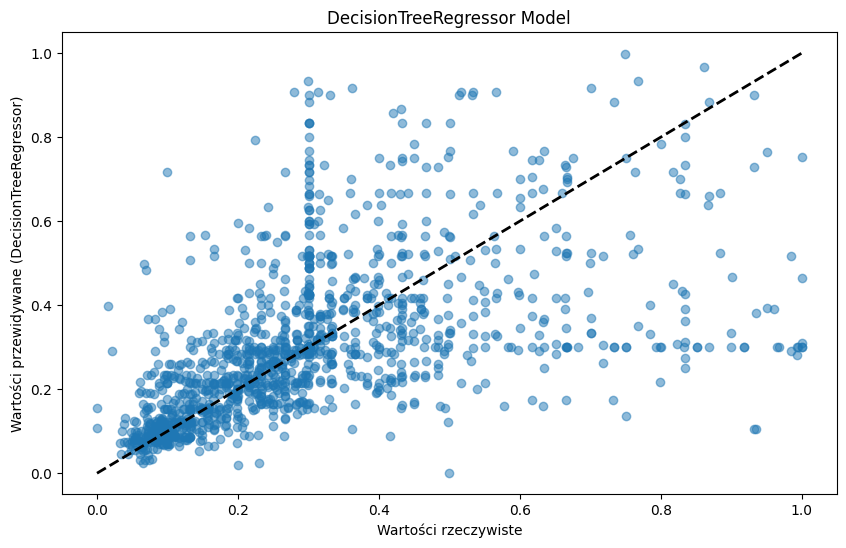

In [57]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(random_state=42)

dt_regressor.fit(X_train, y_train)

y_pred_dt = dt_regressor.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
evs_dt = explained_variance_score(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecisionTreeRegressor Results:")
print(f"Średni błąd kwadratowy (MSE): {mse_dt:.2f}")
print(f"Średni błąd absolutny (MAE): {mae_dt:.2f}")
print(f"Wynik wyjaśnionej wariancji (EVS): {evs_dt:.2f}")
print(f"Współczynnik determinacji (R-squared): {r2_dt:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidywane (DecisionTreeRegressor)')
plt.title('DecisionTreeRegressor Model')
plt.show()